#### Test file for developing krigging method 

1) Take all Drifters at a given date 
2) Produce krigging velococity field over that date 
3) Apply this velocity onto the cmems output somehow 

Notes: 
- there will be 77 dFADs in domain but only 15 show up within 2 hours of target time 
- Some of this could be from some that send more than 2 hours
- some could be from those that leave and reenter the domain - are still counted as "active" this way
- Also ones with removed datapoints ( stuck on reef ex)

In [352]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import xarray as xr
import pykrige as pk 
from pykrige.ok import OrdinaryKriging
from pykrige.uk import UniversalKriging
import geopandas as gpd 
from functions.funcs import *

1) Take Drifters at specific time for Example

In [353]:
ds = gpd.read_parquet(r"Data\Mapped_SAT_MI_Cleanedspeeds.parquet")

In [354]:
def dFADS_in_domain(data:gpd.geodataframe):
    mindate = data["MinOfDate"].min()
    maxdate = data["MaxOfDate"].max()
    mindate = mindate.floor('D')
    maxdate = maxdate.floor('D')
    entrydates = pd.DataFrame({"Dates":data["MinOfDate"].dt.floor('D')})
    exitdates = pd.DataFrame({"Dates":data["MaxOfDate"].dt.floor('D')})
    entrydates["Value"] = 1
    exitdates["Value"] = -1

    DateRange = pd.date_range(start = mindate,end = maxdate)
    DateRange = pd.DataFrame({"Dates":DateRange})
    combineddates = pd.concat([entrydates,exitdates]).sort_values("Dates")
    daily_changes = combineddates.groupby('Dates')['Value'].sum().reset_index()
    daily_changes = pd.merge(DateRange, daily_changes, on = "Dates", how = "left").fillna(0)
   # print(daily_changes)
    daily_changes["active_dFADs"] = daily_changes['Value'].cumsum()
    #print(daily_changes)
    return daily_changes

In [355]:
daily_changes = dFADS_in_domain(ds)
target  = daily_changes.iloc[685] ## Picked a random Date that had a larger(but kinda average amount of fads)
target_date = target.Dates
print(f"target date is : {target_date} with {target.active_dFADs} FADs" )


target date is : 2023-05-14 00:00:00 with 109.0 FADs


In [356]:
def active_fads_at_date(data:gpd.GeoDataFrame, date):
    data = data.query("MinOfDate <= @date")
    data = data.query("MaxOfDate >= @date")
    return data

ds_active = active_fads_at_date(ds, date = target_date) ## All of the active dFADs at this time 
ds_active = ds_active.reset_index()

columns = ["TimeStamp", "x_speed", "y_speed"]
ds_locations = pd.DataFrame()
for label in columns: 
    longlist = Column_to_List(ds_active, label) 
    ds_locations[label] = longlist
lat, lon  = list_of_latlon(ds_active, droplast= False)
ds_locations["lat"] = lat
ds_locations["lon"] =lon
ds_locations.TimeStamp = pd.to_datetime(ds_locations.TimeStamp)

##Filter Timestep by certain threshhold to get locations of FADS within closes  
## UPDATE:This might be better to interp these onto the specific time. 
hourlim = 2
time_threshhold  = pd.Timedelta(hours= hourlim)
time_upper  = target_date +time_threshhold
time_lower = target_date - time_threshhold
ds_locations = ds_locations.query(f"TimeStamp > @time_lower")
ds_locations = ds_locations.query(f"TimeStamp < @time_upper")
print(f"Amount of sampled dFAD within {hourlim} hrs : {len(ds_locations)}")

Amount of sampled dFAD within 2 hrs : 53


2) Making the Kriging Velocities 

In [357]:
data = xr.open_dataset(r"data\cmems.nc")
dataNWR = gpd.read_file(r"Data\Palmyra_Shapefiles",  layer = 'PAL_KING_NWR_12nm')
lats = data.latitude
lons = data.longitude
slice = data.sel(time= target_date,depth = 15, method= "nearest")


In [358]:
### Adding in the Krigging
x = OrdinaryKriging(
        ds_locations.lon, ds_locations.lat, ds_locations.x_speed,
        variogram_model='spherical',
        verbose=False,
        enable_plotting=False
    )

y = OrdinaryKriging(
        ds_locations.lon, ds_locations.lat, ds_locations.y_speed,
        variogram_model='spherical',
        verbose=False,
        enable_plotting=False
    )

z_predx, ss_x = x.execute('grid', lons, lats)
z_predy, ss_y = y.execute('grid', lons, lats)


In [359]:
print(ss_x.mean())

0.012035147815649176


##### Making plots compairing the dFADS locs and CMEMS

In [360]:
print(str(target.Dates))

2023-05-14 00:00:00


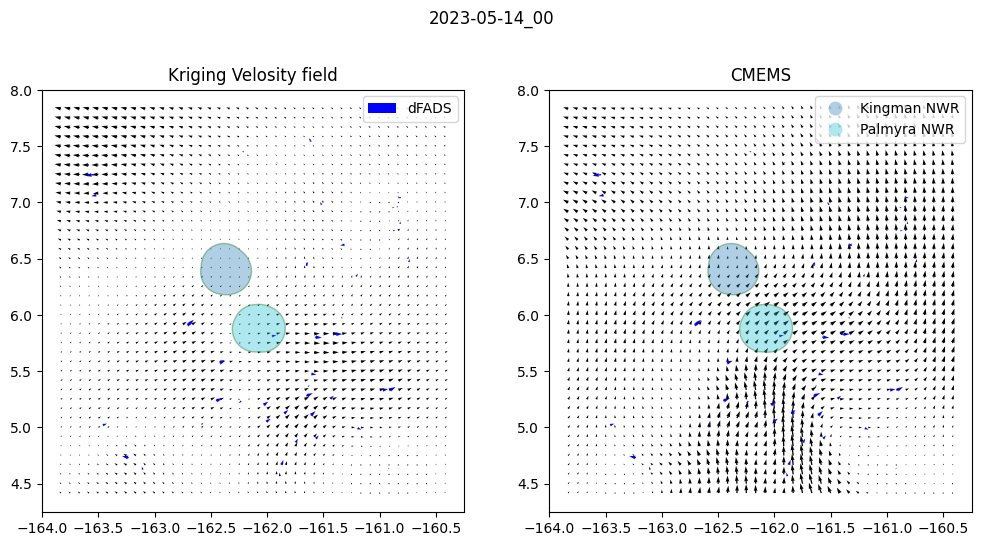

In [ ]:
X, Y = np.meshgrid(lons, lats)

fig , ax = plt.subplots(1,2, figsize = (12,6))
scale = 5

# Plotting Varience underneath 
# ax[0].contourf(X,Y,ss_x + ss_y, zscore = 1, alpha =0.5)
# ax[1].contourf(X,Y,ss_x + ss_y, zscore = 1, alpha =0.5)

ax[0].quiver(X,Y, z_predx, z_predy, scale=scale, scale_units='xy', angles='xy', width = 0.003)
ax[0].quiver(ds_locations.lon, ds_locations.lat, ds_locations.x_speed, ds_locations.y_speed, 
             color = "blue", scale=scale, scale_units='xy', angles='xy',width = 0.003, label = "dFADS")

ax[1].quiver(X,Y, slice.uo, slice.vo, scale=scale, scale_units='xy', angles='xy', width = 0.003)
ax[1].quiver(ds_locations.lon, ds_locations.lat, ds_locations.x_speed, ds_locations.y_speed, 
             color = "blue", scale=scale, scale_units='xy', angles='xy',width = 0.003)

##Labels and style
ax[0].set_title("Kriging Velosity field")
ax[1].set_title("CMEMS")
plot_NWPs(ax[0], dataNWR)
plot_NWPs(ax[1], dataNWR)
ax[0].legend()
date = target.Dates.strftime('%Y-%m-%d_%H')
fig.suptitle(f"{date}, Number of Points: {len(ds_locations)}")
fig.savefig(fr"..\Figures\Krigging\{date}.png")

In [362]:
slice = data.sel(time= data.time[0],depth = 15, method= "nearest")

In [363]:
def make_example_speeds(data:xr.Dataset, number:int, adjustemnt:float, variablity:float):
    y = len(data.latitude)
    x = len(data.longitude)
    speeds = []
    lats =[]
    lons = []
    originalspeeds = []
    adjustemnts = (np.random.random(number)*variablity-0.5) + adjustemnt  ## creates the random variablity in dfad speeds. 
    for n in range(number):
        i = np.random.randint(0,x)
        j = np.random.randint(0,y)
        lats.append(data.latitude[j].to_numpy())
        lons.append(data.longitude[i].to_numpy())
        speeds.append(float(data.uo[j,i].to_numpy().tolist()) + adjustemnts[n])
        originalspeeds.append(float(data.uo[j,i].to_numpy().tolist()))
    return pd.DataFrame({"latitude": lats, "longitude":lons, "speed": speeds,"modelspeeds": originalspeeds})


In [364]:
dfads = make_example_speeds(slice, 5, 0.3,0.5)